In [ ]:
#Task 1 - Find the min, max, mean and std for each column using numpy

from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["Price"] = data.target

for col in df.columns:
    print(col)
    print('min:', np.min(df[col]))
    print('max:', np.max(df[col]))
    print('mean:', np.mean(df[col]))
    print('std:', np.std(df[col]))
    print()

MedInc
min: 0.4999
max: 15.0001
mean: 3.8706710029069766
std: 1.8997756945748738

HouseAge
min: 1.0
max: 52.0
mean: 28.639486434108527
std: 12.585252725724606

AveRooms
min: 0.8461538461538461
max: 141.9090909090909
mean: 5.428999742190376
std: 2.474113202333516

AveBedrms
min: 0.3333333333333333
max: 34.06666666666667
mean: 1.096675149606208
std: 0.4738993762577447

Population
min: 3.0
max: 35682.0
mean: 1425.4767441860465
std: 1132.4346877576147

AveOccup
min: 0.6923076923076923
max: 1243.3333333333333
mean: 3.0706551594363742
std: 10.385797959128217

Latitude
min: 32.54
max: 41.95
mean: 35.63186143410852
std: 2.135900653797483

Longitude
min: -124.35
max: -114.31
mean: -119.56970445736432
std: 2.003483187746976

Price
min: 0.14999
max: 5.00001
mean: 2.0685581690891475
std: 1.153928204041225



In [5]:
#Task 2 - Find if there is any correlation between HouseAge and price

from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["Price"] = data.target

print('Correlation between HouseAge and Price:', df['HouseAge'].corr(df['Price']))

Correlation between HouseAge and Price: 0.10562341249320992


In [6]:
#Task 3 - Find if there is any correlation between AveRooms and price

from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["Price"] = data.target

print('Correlation between AveRooms and Price:', df['AveRooms'].corr(df['Price']))

Correlation between AveRooms and Price: 0.15194828974145774


In [7]:
#Task 4 - Find if there is any correlation between AveBedrms and price

from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["Price"] = data.target

print('Correlation between AveBedrms and Price:', df['AveBedrms'].corr(df['Price']))

Correlation between AveBedrms and Price: -0.04670051296948687


In [9]:
#Task 5 - Remove the highly correlated values (except of price) and remove them

from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["Price"] = data.target

matrix = df.corr()

to_remove = []
for i in range(len(matrix)):
    for j in range(i + 1, len(matrix)):
        if abs(matrix.iloc[i, j]) > 0.9:
            col_name = matrix.columns[j]
            if col_name not in to_remove and col_name != 'Price':
                to_remove.append(col_name)

new_df = df.drop(columns=to_remove)
print("\nRemaining columns:")
for col in new_df.columns:
    print(" -", col)


Remaining columns:
 - MedInc
 - HouseAge
 - AveRooms
 - AveBedrms
 - Population
 - AveOccup
 - Latitude
 - Price


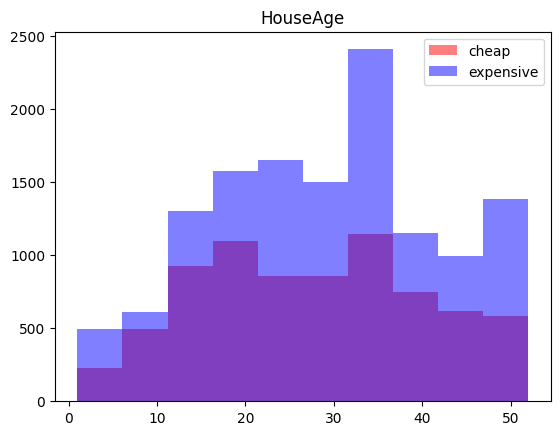

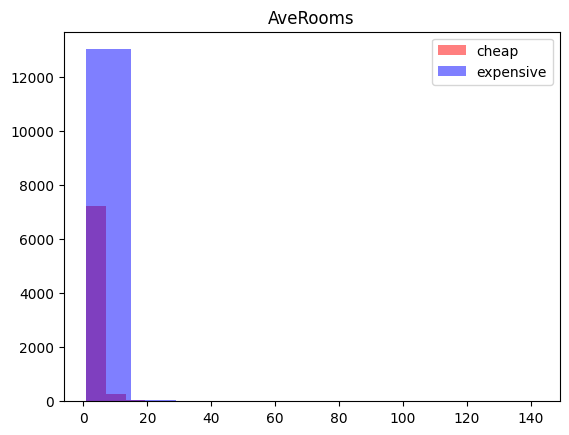

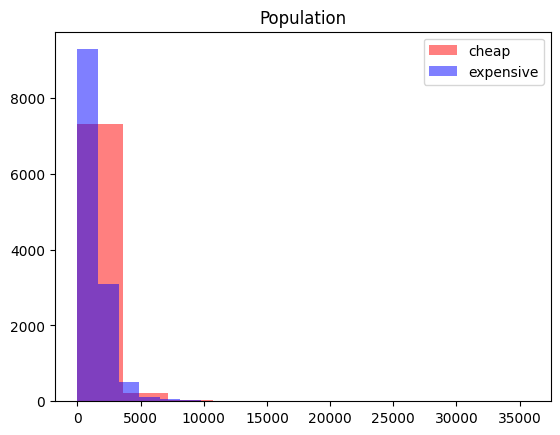

In [15]:
#Task 6 -Define the function to make solving the following problems - it will be easier.

#Compare how different are the distributions for HouseAge for the houses which cost less than 1.5
#Compare how different are the distributions for AveRooms for the houses which cost less than 1.5
#Compare how different are the distributions for Population for the houses which cost less than 1.5

from sklearn.datasets import fetch_california_housing
import pandas as pd
import matplotlib.pyplot as plt

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["Price"] = data.target

def compare_distributions(col):
    cheap = df[df['Price'] < 1.5][col]
    expensive = df[df['Price'] >= 1.5][col]
    
    plt.hist(cheap, alpha=0.5, label='cheap', color='red')
    plt.hist(expensive, alpha=0.5, label='expensive', color='blue')
    plt.title(col)
    plt.legend()
    plt.show()

compare_distributions('HouseAge')
compare_distributions('AveRooms')
compare_distributions('Population')

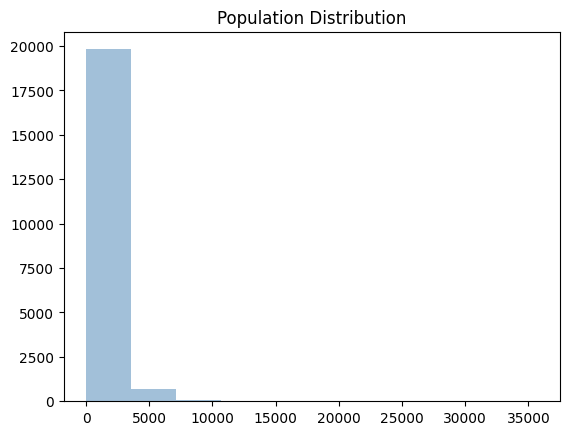

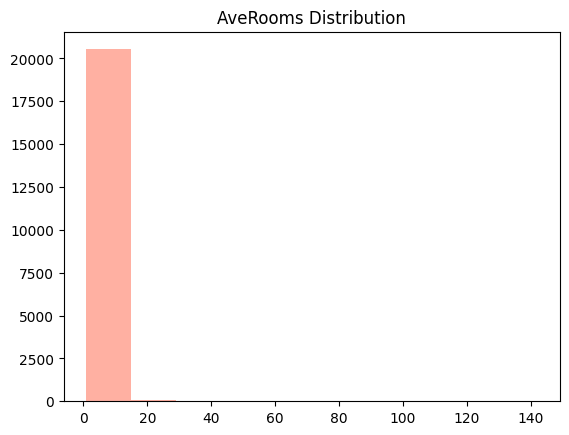


Population is high which means demand is high.
This is a sellers market where sellers control the price.
They set it high due to the demand.
Thus population is more important for price prediction.



In [ ]:
#Task 7 - Compare global distributions between Population and AveRooms

#What do you think, which column is more important for price prediction, HouseAge, AveRooms, AveBedrms or Population and why
#You may have the assumption on this question without using machine learning

from sklearn.datasets import fetch_california_housing
import pandas as pd
import matplotlib.pyplot as plt

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["Price"] = data.target

plt.hist(df['Population'], color='steelblue', alpha=0.5)
plt.title('Population Distribution')
plt.show()

plt.hist(df['AveRooms'], color='tomato', alpha=0.5)
plt.title('AveRooms Distribution')
plt.show()

print("""
Population is high which means demand is high.
This is a sellers market where sellers control the price.
They set it high due to the demand.
Thus population is more important for price prediction.
""")